## Data Processing

### Setup

In [1]:
import os
import multiprocessing
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms

import nibabel as nib
import albumentations as alb

/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Data Paths

In [3]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 1
  - T1: 1
  - T1ce: 1
  - T2: 1
  - Seg: 1
Missing files at: ['../data/brats2021/BraTS2021_00539']


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [4]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (300, 6)
Validation set shape: (38, 6)
Test set shape: (38, 6)


### Custom Dataset Class

In [6]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        slices = []
        masks = []

        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)

        for i in range(start, end - self.window_size + 1):
            slice_group = np.concatenate([data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i+ self.window_size)], axis=-1)
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))

        return slices, masks
        

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1]
        width = data.shape[2]
        num_modalities = data.shape[0]
        num_slices = self.window_size
        

        mask = nib.load(row.seg_path).get_fdata()
        data, mask = self._get_adjacent_slices(data, mask) 
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)
            
            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]
        
        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

### Transforms

| **Augmentation**    | **Function**                                                                                             | **Reasoning**                                                                                                                                       |
|-------------------------------|-------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Horizontal Flip               | Randomly flips the image horizontally.                                                                                 | Increases training data diversity; however, caution is needed because brain hemispheres can be lateralized, and tumors may show a side-specific distribution.    |
| Rotation                      | Rotates the image by a small angle (±5°).                                                                               | Mimics slight head tilts during MRI acquisition, helping the model learn minor orientation variations without distorting anatomical structures.                  |
| Random Scale                  | Scales the image by a factor within ±8%.                                                                               | Simulates variations in scanner zoom or patient size while preserving the relative sizes of brain structures and tumor-to-brain ratios.                             |
| Elastic Transform             | Applies smooth, local deformations to the image.                                                                       | Mimics realistic soft-tissue deformations in MR images; careful parameter tuning prevents unrealistic warping of critical tumor morphology.                       |
| Affine Transform              | Performs minor translations, rotations, and scaling simultaneously.                                                  | Adjusts for slight differences in patient positioning; maintains anatomical consistency while introducing subtle spatial variability.                           |
| Pad & Resize                  | Pads the image (if necessary) and resizes it to a fixed dimension (e.g., 240×240).                                      | Ensures uniform input dimensions for the network, which is vital for consistent performance and accurate segmentation.                                             |
| Random Brightness/Contrast    | Adjusts brightness and contrast within a moderate range (±15%).                                                        | Reflects variations in imaging conditions and scanner calibration while preserving subtle tumor intensity differences critical for segmentation.                |
| GaussNoise                    | Adds Gaussian noise with moderate variance.                                                                          | Emulates scanner noise found in real MR images, which helps the model become robust to noise without masking important details of tumor boundaries.             |
| Random Gamma Correction       | Modifies the image gamma within a narrow range (98–102).                                                               | Maintains clinically relevant intensity distributions and preserves tumor contrast, ensuring that subtle intensity variations remain interpretable.              |
| Median Blur                   | Applies a slight blur to reduce noise while preserving edges.                                                        | Helps in reducing high-frequency noise and artifacts without losing the sharp boundaries needed for precise delineation of tumor margins.                         |


In [7]:
transformations = {}
spatial_transforms = alb.Compose([
    alb.HorizontalFlip(p=0.3),
    alb.Rotate(limit=5, p=0.3),
    alb.RandomScale(scale_limit=0.08, p=0.3),
    # alb.ElasticTransform(alpha=1, sigma=2.5, p=0.2),
    # alb.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), rotate=(-5, 5), p=0.3, fit_output=False),
    alb.PadIfNeeded(min_height=240, min_width=240),
    alb.Resize(240, 240)
], additional_targets={"mask":"mask"})
intensity_transforms = alb.Compose([
    alb.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    alb.GaussNoise(p=0.3),
    alb.RandomGamma(gamma_limit=(90,110), p=0.3),
    alb.MedianBlur(blur_limit=3, p=0.2),
])
transformations['spatial_transforms'] = spatial_transforms
transformations['intensity_transforms'] = None

In [8]:
upper_bound=100
lower_bound=60 
window_size = 3
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=transformations)
data, mask = test_data[0]
print(f"Number of Datapoits: {len(data)}")
print(f"Data Shape: {data[0].shape}")
print(f"Mask Shape: {mask[0].shape}")

Number of Datapoits: 38
Data Shape: (4, 3, 240, 240)
Mask Shape: (240, 240)


Text(0.5, 1.0, 'Mask')

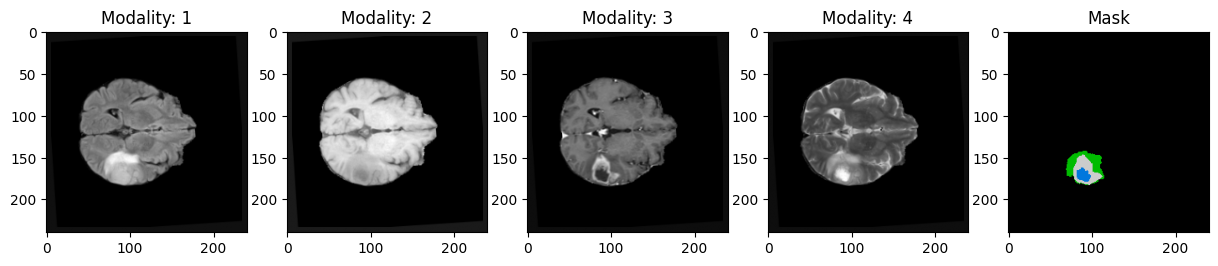

In [258]:
data_point_idx = np.random.randint(len(data)-1)
batch_idx = np.random.randint(upper_bound-lower_bound)
data, mask = test_data[data_point_idx]
anchor_slice = window_size//2

plt.figure(figsize=(15,15))

for i in range(data[batch_idx].shape[0]):
    plt.subplot(4,5,i+1)
    plt.imshow(data[batch_idx][i,anchor_slice, :,:], cmap="gray")
    plt.title(f"Modality: {i+1}")

plt.subplot(4,5,i+2)
plt.imshow(mask[batch_idx], cmap="nipy_spectral")
plt.title("Mask")

### Dataloader

In [10]:
upper_bound=100
lower_bound=60 
window_size = 3
train_data = BrainTumorDataset(dataset_train,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=transformations)
val_data = BrainTumorDataset(dataset_val,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=None)
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=None)
pd.Series({
    'Training dataset size:': len(train_data),
    'Validation dataset size:': len(val_data),
    'Testing dataset size:': len(test_data)
}).to_frame().style.hide(axis='columns')

Training dataset size:,300
Validation dataset size:,38
Testing dataset size:,38


In [11]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = multiprocessing.cpu_count()//2
num_workders = -1
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
train_dataloader = DataLoader(train_data, **data_loader_params, shuffle=True)
val_dataloader = DataLoader(val_data, **data_loader_params)
test_dataloader = DataLoader(test_data, **data_loader_params)

Number of datapoints per batch 76


/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 14 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [12]:
pd.Series({
    'Number of batches in train dataLoader:': len(train_dataloader),
    'Number of batches in validation dataLoader:': len(val_dataloader),
    'Number of batches in test dataLoader:': len(test_dataloader)
}).to_frame().style.hide(axis='columns')

Number of batches in train dataLoader:,150
Number of batches in validation dataLoader:,19
Number of batches in test dataLoader:,19


In [13]:
for batch_idx, (data, mask) in enumerate(train_dataloader):
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Batch 0:
  Data shape: torch.Size([76, 4, 3, 240, 240])
  Mask shape: torch.Size([76, 240, 240])


## Model Training

### Setup

In [15]:
import torch
import segmentation_models_pytorch as smp
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.nets import UNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from opacus.validators import ModuleValidator
from opacus import PrivacyEngine

In [3]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Model

#### UNETR

In [41]:
class UNETR_V0(torch.nn.Module):
    def __init__(self,):
        super(UNETR_V0, self).__init__()
        self.unetr = UNETR(
                            in_channels=4,       # Number of input channels (modalities) → T1, T2, FLAIR, T1ce
                            out_channels=4,      # Number of output segmentation classes (1 = binary, >1 = multi-class)
                            
                            img_size=(16, 240, 240),  # Input size → (Depth slices, Height, Width)
                            # patch_size=(1, 16, 16), # Visual token size
                            
                            feature_size=16,     # Base feature size of the encoder (affects transformer token dimensions)
                            hidden_size=768,     # Transformer hidden size (same as ViT/UNETR)
                            mlp_dim=3072,        # MLP feed-forward layer dimension (typically 4×hidden_size)
                            
                            num_heads=12,        # Number of self-attention heads in transformer blocks (higher = more expressive)
                            proj_type="perceptron",  # Type of projection (alternative is "conv" for convolutional projection)
                            
                            norm_name="instance", # Type of normalization → "instance" (better for medical images) or "batch"
                            res_block=True,      # Use residual connections in CNN decoder blocks (helps gradient flow)
                            
                            dropout_rate=0.1,    # Dropout applied in transformer layers (0.0 = no dropout, useful in small datasets)
                        )
    def forward(self, X):
        X = self.unetr(X)
        return X

In [42]:
dummy_input = torch.randn((2, 4, 16, 240, 240))
unetr = UNETR_V0().to('cuda')
dummy_output = unetr(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 16, 240, 240])

Conclusion
- Model is too big for 12G GPU.
- UNETR can't process depth of 3. It has to be larger >=16

Resolution
- UNET for 2D segmention where modalities and depth are combined.
- Add attention to get optimal weightage.

#### UNET With Merged Modalities & Depth - Attention, No residuals.

In [5]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=12,       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 2, 2),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.1,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [6]:
dummy_input = torch.randn((2, 12, 240, 240))
unet = UNET_V0().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 240, 240])

#### UNET With Merged Modalities & Depth - Pretrained Weight + Residuals + Attention (Only 2D)

In [10]:
class UNET_V1(torch.nn.Module):
    def __init__(self,):
        super(UNET_V1, self).__init__()
        self.unet = smp.Unet(
                    encoder_name="resnet50",        # Encoder: resnet34/ efficientnet-b0 / resnet50
                    encoder_weights="imagenet",     # Pre-trained on ImageNet
                    in_channels=12,                  # Number of input channels (e.g., RGB images)
                    classes=4,                      # Number of segmentation classes
                    activation="softmax2d",         # Multi-class segmentation requires softmax activation
                    decoder_attention_type="scse",  # Spatial and Channel Squeeze & Excitation (SCSE) attention
                )

    def forward(self, X):
        X = self.unet(X)
        return X

In [12]:
dummy_input = torch.randn((2, 12, 256, 256))
unet = UNET_V1().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 256, 256])

#### UNET++ With Merged Modalities & Depth - Pretrained Weight + Residuals + Attention (Only 2D)

In [44]:
class UNET_V2(torch.nn.Module):
    def __init__(self,):
        super(UNET_V2, self).__init__()
        self.unet = smp.UnetPlusPlus(
                    encoder_name="resnet50",        # Encoder: resnet34/ efficientnet-b0 / resnet50
                    encoder_weights="imagenet",     # Pre-trained on ImageNet
                    in_channels=12,                  # Number of input channels (e.g., RGB images)
                    classes=4,                      # Number of segmentation classes
                    activation="softmax2d",         # Multi-class segmentation requires softmax activation
                    decoder_attention_type="scse",  # Spatial and Channel Squeeze & Excitation (SCSE) attention
                )

    def forward(self, X):
        X = self.unet(X)
        return X

In [45]:
dummy_input = torch.randn((2, 12, 256, 256))
unet = UNET_V2().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 256, 256])

#### UNET With Depth - Attention, No residuals.

In [46]:
class UNET_V3(torch.nn.Module):
    def __init__(self,):
        super(UNET_V3, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=3,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=4,       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(1, 1, 1, 2),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.1,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [47]:
dummy_input = torch.randn((2, 4, 3, 240, 240))
unet = UNET_V3().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

torch.Size([2, 4, 3, 240, 240])

In [15]:
# Discard 0 and 2, propogate loss for only 1
dummy_output[:,:,1,:,:] # torch.Size([2, 4, 240, 240])
torch.argmax(dummy_output[:,:,1,:,:], dim=1) # torch.Size([2, 240, 240])
print()

In [9]:
dummy_input = torch.randn((2, 12, 240, 240))
dummy_input.reshape((2,3,4,240,240)).shape

torch.Size([2, 3, 4, 240, 240])

### Hyperperameters

In [48]:
def define_optimizer_and_lr(model):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = T_max)
    return optimizer, lr_scheduler

In [49]:
lr = 1e-4
weight_decay = 1e-3
steps = 10
T_max = 100

isDP = True
noise_multiplier = 1.2
max_grad_norm = 1.0 

model =  UNET_V0().to(device)
loss = DiceLoss(to_onehot_y=True, softmax=True)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# Instantiation
# optimizer, lr_scheduler = define_optimizer_and_lr(model)

### Differential Privacy

In [50]:
def differential_privacy(model, dataloader, noise_multiplier, max_grad_norm):
    model = ModuleValidator.fix(model)
    ModuleValidator.validate(model, strict=False)
    optimizer, lr_scheduler = define_optimizer_and_lr(model)
    privacy_engine = PrivacyEngine()
    model, optimizer, dataloader = privacy_engine.make_private(
        module = model,
        optimizer = optimizer,
        data_loader = dataloader,
        noise_multiplier=noise_multiplier,  # Higher = more privacy, but more noise
        max_grad_norm=max_grad_norm,  # Clipping to ensure DP
    )
    return model, optimizer, lr_scheduler, dataloader

In [51]:
# Instantiation

# if isDP:
#     model, optimizer, lr_scheduler, train_dataloader = differential_privacy(model, train_dataloader, noise_multiplier, max_grad_norm)

### Training Loop